# 03. MLP

This notebook trains a `MLP` baseline on the wallet-level table.

Included by default:

- stratified train/val/test split
- validation-based threshold tuning
- rich test metrics
- ROC curve, PR curve, confusion matrix, score histogram, threshold sweeps, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- only wallet feature columns are used


In [9]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    classification_report_df,
    fit_and_evaluate_model,
    plot_evaluation_dashboard,
    plot_feature_importance,
    plot_mlp_learning_curve,
    set_seed,
)


In [10]:
MODEL_NAME = "mlp"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [11]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))
print("Scale positive weight:", round(dataset["scale_pos_weight"], 4))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 8
Scale positive weight: 7.8832


In [12]:
result = fit_and_evaluate_model(
    model_name=MODEL_NAME,
    dataset=dataset,
    random_state=RANDOM_STATE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

metrics_df = pd.DataFrame([result["metrics"]]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.150000
PR-AUC,0.459325
ROC-AUC,0.813934
F1,0.431487
Precision,0.425287
Recall,0.437870
Specificity,0.924869
NPV,0.928356
Balanced-Accuracy,0.681369
MCC,0.358162


In [13]:
report_df = classification_report_df(
    dataset["y_test"].to_numpy(),
    result["test_prob"],
    result["threshold"],
)
display(report_df)


,precision,recall,f1-score,support
0,0.928356,0.924869,0.926609,1331.00
1,0.425287,0.437870,0.431487,169.00
accuracy,0.870000,0.870000,0.870000,0.87
macro avg,0.676822,0.681369,0.679048,1500.00
weighted avg,0.871677,0.870000,0.870825,1500.00


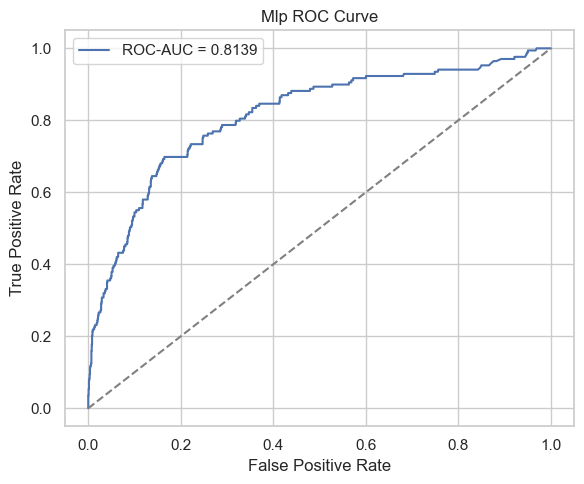

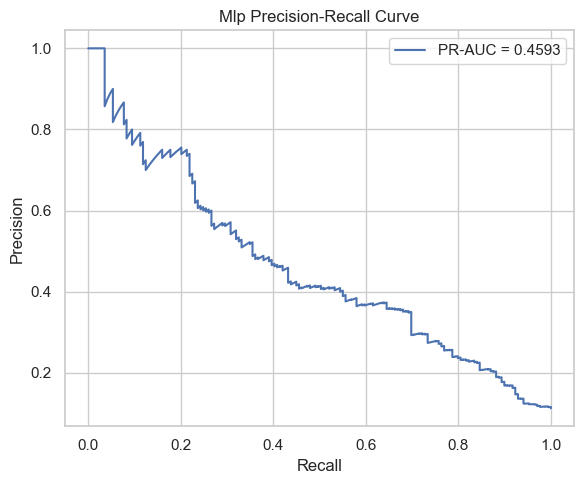

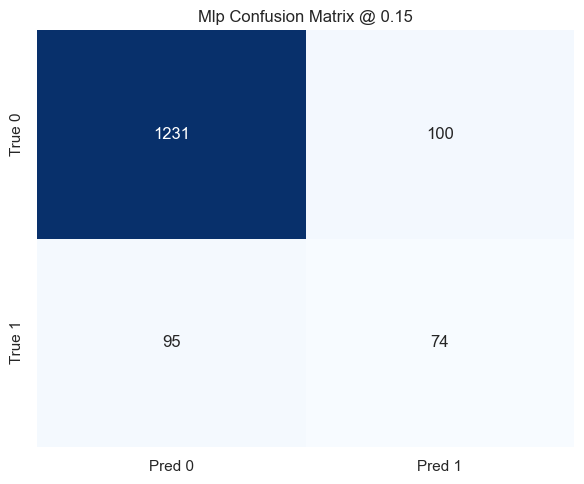

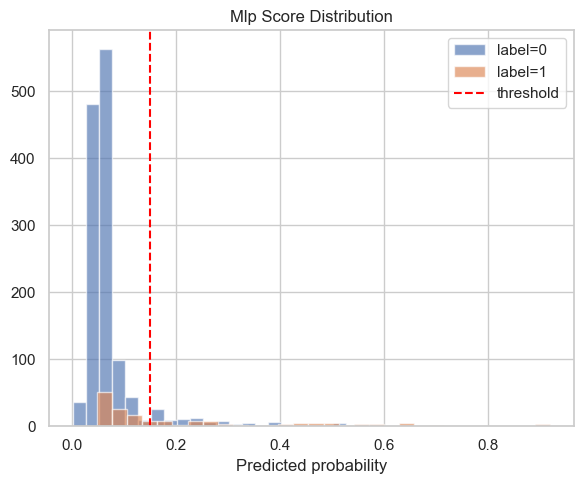

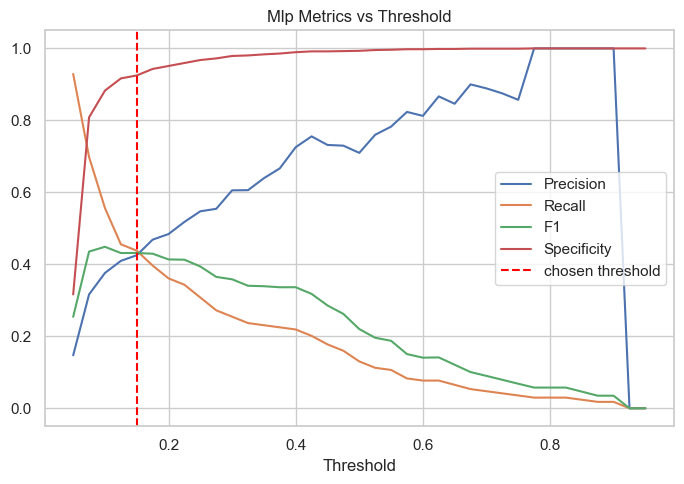

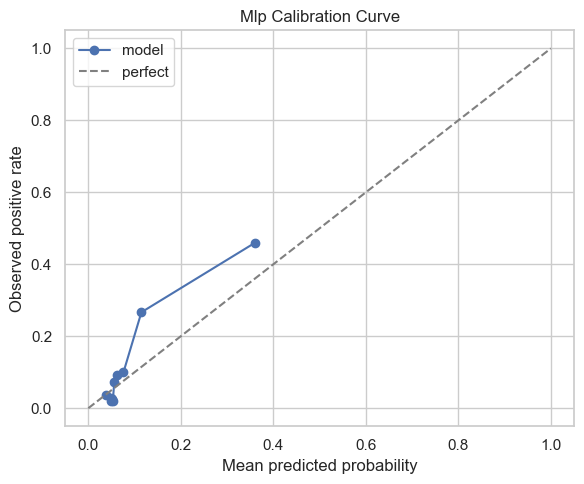

In [14]:
plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=result["test_prob"],
    threshold=result["threshold"],
    title_prefix=MODEL_NAME.replace("_", " ").title(),
)


In [15]:
test_node_rows = dataset["nodes_df"].loc[dataset["test_idx"]].copy()
test_node_rows["predicted_probability"] = result["test_prob"]
test_node_rows["predicted_label"] = (result["test_prob"] >= result["threshold"]).astype(int)
suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
2046,258361,1,0.920238,1,2,0
1834,235606,1,0.910859,1,5,5
1539,204115,1,0.906663,1,1,1
2478,308537,1,0.869196,1,1,1
2209,276703,1,0.827764,1,1,0
2732,341302,1,0.766888,1,4,2
2200,275857,0,0.753420,1,65,7
1807,233182,1,0.745024,1,1,1
3190,393745,1,0.713249,1,30,6
1664,217839,1,0.696925,1,11,8


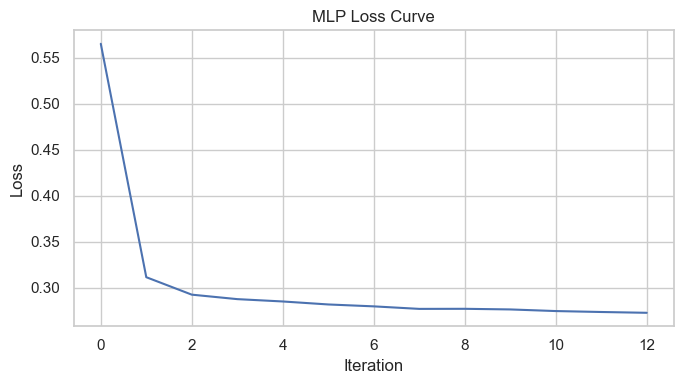

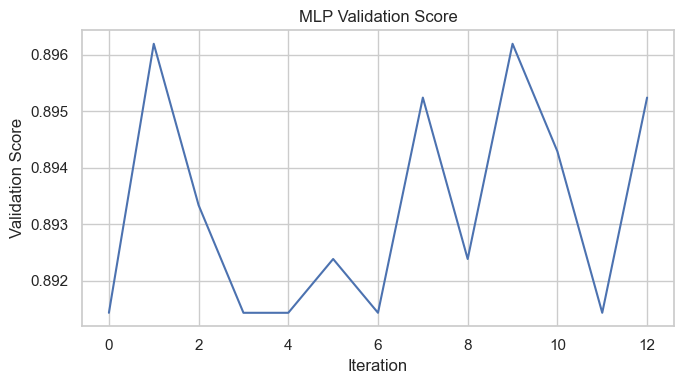

In [16]:
plot_mlp_learning_curve(result["model"])


## Notes

Use `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing this model with the other baselines.
